# Loan Default Prediction — EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

df = pd.read_csv('loan_applications_V0.csv')
print(df.shape)
df.head()

(2000, 15)


,applicant_id,stated_monthly_income,documented_monthly_income,loan_amount,employment_status,bank_ending_balance,bank_has_overdrafts,bank_has_consistent_deposits,monthly_withdrawals,monthly_deposits,num_documents_submitted,rule_based_score,rule_based_decision,actual_outcome,days_to_default
0,APP-0000,3683.0,3462.0,2000,employed,3084.0,False,True,1927.0,3337.0,1,67.7,flagged_for_review,repaid,NaN
1,APP-0001,2011.0,1880.0,1500,unemployed,1525.0,False,True,776.0,1844.0,2,57.3,flagged_for_review,repaid,NaN
2,APP-0002,820.0,201.0,1500,self_employed,4091.0,False,True,145.0,180.0,2,30.9,denied,repaid,NaN
3,APP-0003,5551.0,5264.0,3000,employed,772.0,False,True,1747.0,4549.0,1,69.7,flagged_for_review,ongoing,NaN
4,APP-0004,6370.0,5880.0,2000,employed,2254.0,False,True,4673.0,5222.0,2,87.1,approved,repaid,NaN


## 1. Data Quality & Missingness

In [3]:
# What's missing, and is it random or meaningful?
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0'))

# Is documented_monthly_income missing at random, or does it correlate with default?
df['has_documentation'] = df['documented_monthly_income'].notna().astype(int)
print('\nDefault rate by documentation status:')
print(df[df.actual_outcome != 'ongoing'].groupby('has_documentation')['actual_outcome']
      .apply(lambda x: (x == 'defaulted').mean()).rename('default_rate').round(3))

                           missing_count  missing_pct
documented_monthly_income            283         14.2
days_to_default                     1455         72.8

Default rate by documentation status:
has_documentation
0    0.492
1    0.265
Name: default_rate, dtype: float64


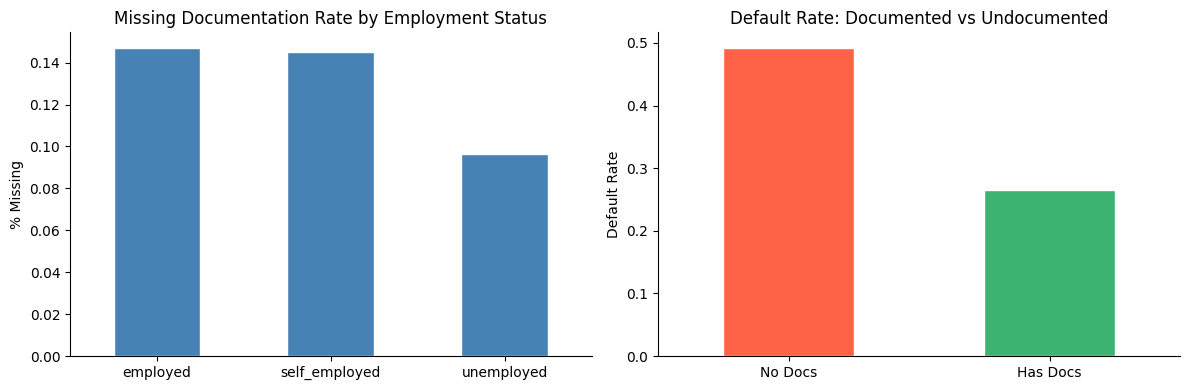

TAKEAWAY: Undocumented applicants default at a higher rate — missingness is NOT random. has_documentation is a useful feature.


In [4]:
# Visualize: missing documentation vs outcome
# KEY INSIGHT: if undocumented applicants default more, missingness is informative — not random
known = df[df.actual_outcome != 'ongoing'].copy()
known['defaulted'] = (known.actual_outcome == 'defaulted').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: missing rate by employment status
miss_by_emp = df.groupby('employment_status')['has_documentation'].apply(lambda x: (x==0).mean())
miss_by_emp.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Missing Documentation Rate by Employment Status')
axes[0].set_ylabel('% Missing')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Right: default rate by documentation status
def_by_docs = known.groupby('has_documentation')['defaulted'].mean()
def_by_docs.index = ['No Docs', 'Has Docs']
def_by_docs.plot(kind='bar', ax=axes[1], color=['tomato', 'mediumseagreen'], edgecolor='white')
axes[1].set_title('Default Rate: Documented vs Undocumented')
axes[1].set_ylabel('Default Rate')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('plot_01_missingness.png', dpi=150, bbox_inches='tight')
plt.show()
print('TAKEAWAY: Undocumented applicants default at a higher rate — missingness is NOT random. has_documentation is a useful feature.')

## 2. Target Variable & Class Imbalance

In [5]:
# How imbalanced is the target? And how do we handle 'ongoing'?
print('All outcomes:')
print(df.actual_outcome.value_counts())
print(f'\nongoing = {(df.actual_outcome=="ongoing").mean():.1%} of data')
print('\nAmong known outcomes only:')
known_outcomes = df[df.actual_outcome != 'ongoing']
print(known_outcomes.actual_outcome.value_counts())
print(f'Default rate (known only): {(known_outcomes.actual_outcome=="defaulted").mean():.1%}')

All outcomes:
actual_outcome
repaid       1291
defaulted     545
ongoing       164
Name: count, dtype: int64

ongoing = 8.2% of data

Among known outcomes only:
actual_outcome
repaid       1291
defaulted     545
Name: count, dtype: int64
Default rate (known only): 29.7%


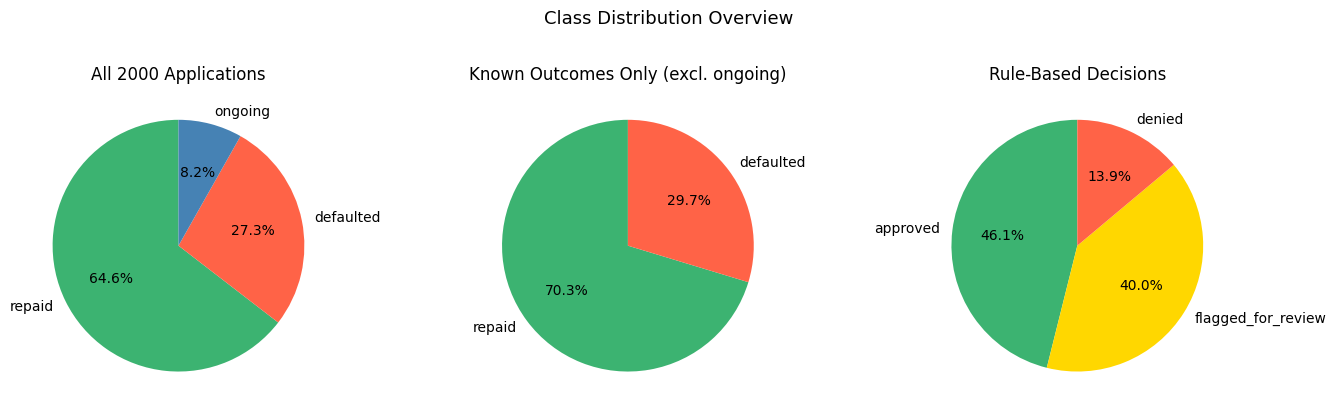

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# All outcomes
counts_all = df.actual_outcome.value_counts()
axes[0].pie(counts_all, labels=counts_all.index, autopct='%1.1f%%', startangle=90,
            colors=['mediumseagreen', 'tomato', 'steelblue'])
axes[0].set_title('All 2000 Applications')

# Known outcomes only
counts_known = known_outcomes.actual_outcome.value_counts()
axes[1].pie(counts_known, labels=counts_known.index, autopct='%1.1f%%', startangle=90,
            colors=['mediumseagreen', 'tomato'])
axes[1].set_title('Known Outcomes Only (excl. ongoing)')

# Rule decision breakdown
counts_rule = df.rule_based_decision.value_counts()
colors_rule = {'approved': 'mediumseagreen', 'flagged_for_review': 'gold', 'denied': 'tomato'}
axes[2].pie(counts_rule, labels=counts_rule.index, autopct='%1.1f%%', startangle=90,
            colors=[colors_rule[k] for k in counts_rule.index])
axes[2].set_title('Rule-Based Decisions')

plt.suptitle('Class Distribution Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_02_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Income Misrepresentation Detection

In [7]:
# Engineer the income discrepancy ratio — this should be a strong feature
# Misrepresenters have stated_income ~3x higher than documented_income
docs_only = df[df.has_documentation == 1].copy()
docs_only['income_ratio'] = docs_only['stated_monthly_income'] / docs_only['documented_monthly_income']

print('Income ratio (stated/documented) stats:')
print(docs_only['income_ratio'].describe().round(2))
print(f'\nRatio > 2 (likely misrepresentation): {(docs_only.income_ratio > 2).sum()} applicants')
print(f'Ratio > 3: {(docs_only.income_ratio > 3).sum()} applicants')

Income ratio (stated/documented) stats:
count    1717.00
mean        1.15
std         0.55
min         0.95
25%         0.99
50%         1.03
75%         1.07
max         4.83
Name: income_ratio, dtype: float64

Ratio > 2 (likely misrepresentation): 85 applicants
Ratio > 3: 56 applicants


C:\Users\brarr\AppData\Local\Temp\ipykernel_15580\3063274552.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_ratio = docs_known.groupby('ratio_bucket')['defaulted'].mean()


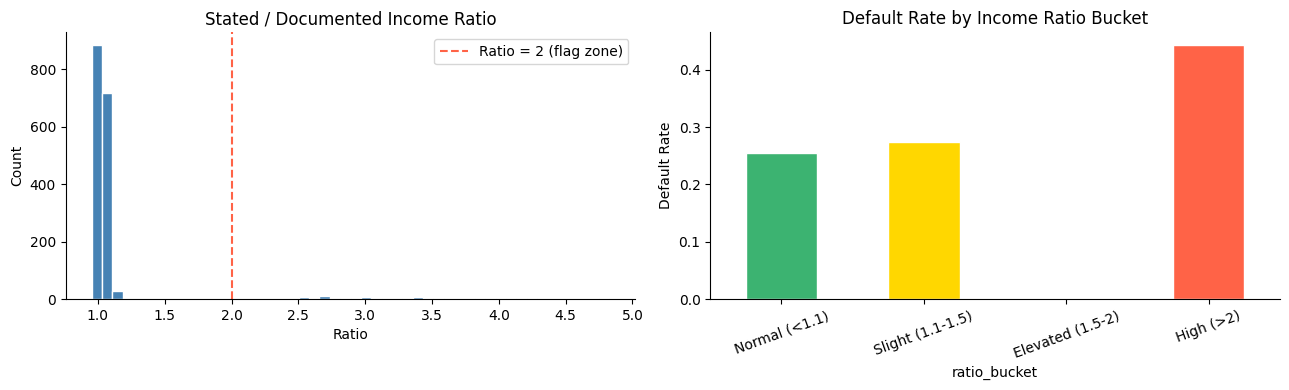

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: distribution of income ratio
axes[0].hist(docs_only['income_ratio'].clip(0, 5), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(2.0, color='tomato', linestyle='--', label='Ratio = 2 (flag zone)')
axes[0].set_title('Stated / Documented Income Ratio')
axes[0].set_xlabel('Ratio')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: default rate by income ratio bucket
docs_known = docs_only[docs_only.actual_outcome != 'ongoing'].copy()
docs_known['defaulted'] = (docs_known.actual_outcome == 'defaulted').astype(int)
docs_known['ratio_bucket'] = pd.cut(docs_known['income_ratio'], bins=[0, 1.1, 1.5, 2.0, 10],
                                     labels=['Normal (<1.1)', 'Slight (1.1-1.5)', 'Elevated (1.5-2)', 'High (>2)'])
default_by_ratio = docs_known.groupby('ratio_bucket')['defaulted'].mean()
default_by_ratio.plot(kind='bar', ax=axes[1], color=['mediumseagreen','gold','orange','tomato'], edgecolor='white')
axes[1].set_title('Default Rate by Income Ratio Bucket')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('plot_03_income_misrepresentation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Key Risk Factors vs Default Rate

In [9]:
# Compute default rates across every categorical risk factor
known = df[df.actual_outcome != 'ongoing'].copy()
known['defaulted'] = (known.actual_outcome == 'defaulted').astype(int)

factors = {
    'employment_status': known.groupby('employment_status')['defaulted'].mean(),
    'bank_has_overdrafts': known.groupby('bank_has_overdrafts')['defaulted'].mean(),
    'bank_has_consistent_deposits': known.groupby('bank_has_consistent_deposits')['defaulted'].mean(),
    'has_documentation': known.groupby('has_documentation')['defaulted'].mean(),
}

for name, series in factors.items():
    print(f'\n{name}:')
    print(series.round(3))


employment_status:
employment_status
employed         0.272
self_employed    0.290
unemployed       0.467
Name: defaulted, dtype: float64

bank_has_overdrafts:
bank_has_overdrafts
False    0.260
True     0.485
Name: defaulted, dtype: float64

bank_has_consistent_deposits:
bank_has_consistent_deposits
False    0.302
True     0.294
Name: defaulted, dtype: float64

has_documentation:
has_documentation
0    0.492
1    0.265
Name: defaulted, dtype: float64


In [10]:
# THE FAIRNESS SETUP: employed vs self_employed default rates
# Rule-based gives employed=100, self_employed=60 — but do they actually default differently?
emp_stats = known.groupby('employment_status').agg(
    n=('defaulted', 'count'),
    default_rate=('defaulted', 'mean'),
    rule_score_mean=('rule_based_score', 'mean'),
    approval_rate=('rule_based_decision', lambda x: (x == 'approved').mean())
).round(3)
print('Employment status analysis:')
print(emp_stats)
print('\nNOTE: If employed and self_employed have similar default rates but very different approval rates, that is bias.')

Employment status analysis:
                      n  default_rate  rule_score_mean  approval_rate
employment_status                                                    
employed           1088         0.272           74.809          0.596
self_employed       566         0.290           64.751          0.355
unemployed          182         0.467           49.537          0.011

NOTE: If employed and self_employed have similar default rates but very different approval rates, that is bias.


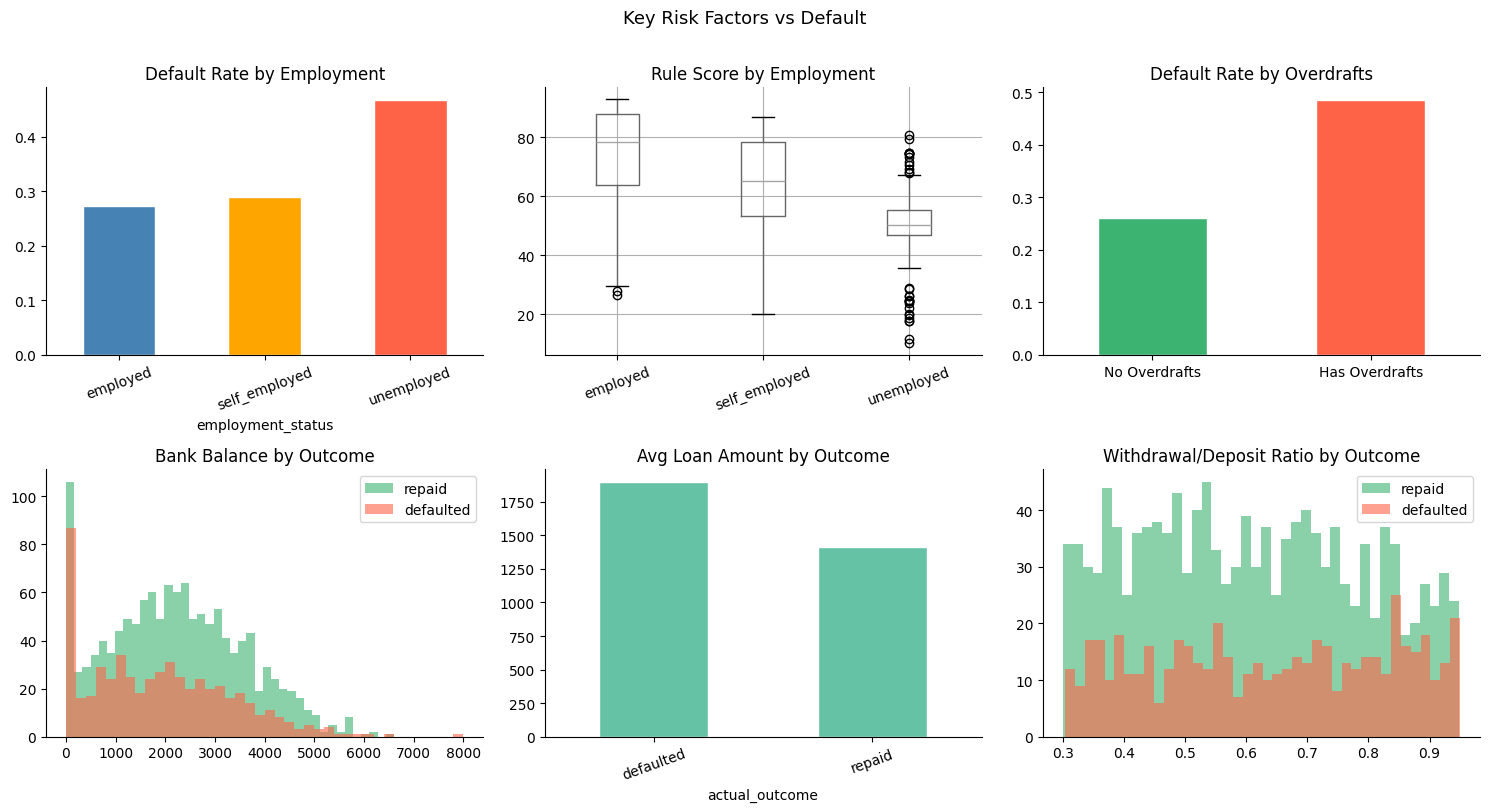

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('loan_applications.csv')
df['has_documentation'] = df['documented_monthly_income'].notna().astype(int)
known = df[df.actual_outcome != 'ongoing'].copy()
known['defaulted'] = (known.actual_outcome == 'defaulted').astype(int)
known['withdrawal_ratio'] = known['monthly_withdrawals'] / known['monthly_deposits'].replace(0, np.nan)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# --- TOP LEFT: Default rate by employment, with sample size annotation ---
emp_stats = known.groupby('employment_status').agg(
    default_rate=('defaulted', 'mean'),
    n=('defaulted', 'count')
).reset_index()
colors = ['#4C9BE8', '#F5A623', '#E84C4C']
bars = axes[0,0].bar(emp_stats['employment_status'], emp_stats['default_rate'],
                      color=colors, edgecolor='white', width=0.5)
# Annotate with sample size and exact %
for bar, (_, row) in zip(bars, emp_stats.iterrows()):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f"{row['default_rate']:.1%}\n(n={row['n']})",
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0,0].set_title('Default Rate by Employment Status', fontweight='bold')
axes[0,0].set_ylabel('Default Rate')
axes[0,0].set_xlabel('')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0,0].set_ylim(0, 0.65)
axes[0,0].tick_params(axis='x', rotation=0)
# Add a note about the fairness issue
axes[0,0].axhline(known['defaulted'].mean(), color='gray', linestyle='--', alpha=0.6, linewidth=1)
axes[0,0].text(2.35, known['defaulted'].mean() + 0.01, 'avg', color='gray', fontsize=8)

# --- TOP MIDDLE: Rule score vs employment — dot plot with mean + range ---
# More readable than a box plot
emp_groups = ['employed', 'self_employed', 'unemployed']
emp_colors = ['#4C9BE8', '#F5A623', '#E84C4C']
for i, (emp, color) in enumerate(zip(emp_groups, emp_colors)):
    subset = known[known.employment_status == emp]['rule_based_score']
    mean = subset.mean()
    p25, p75 = subset.quantile(0.25), subset.quantile(0.75)
    # Draw IQR bar
    axes[0,1].plot([i, i], [p25, p75], color=color, linewidth=6, alpha=0.3, solid_capstyle='round')
    # Draw mean dot
    axes[0,1].scatter(i, mean, color=color, s=120, zorder=5)
    axes[0,1].text(i, mean + 2, f'{mean:.0f}', ha='center', fontsize=10, fontweight='bold', color=color)

axes[0,1].set_xticks([0, 1, 2])
axes[0,1].set_xticklabels(emp_groups)
axes[0,1].set_title('Rule Score by Employment\n(dot = mean, bar = 25th–75th percentile)', fontweight='bold')
axes[0,1].set_ylabel('Rule-Based Score')
axes[0,1].set_ylim(0, 105)
axes[0,1].axhline(75, color='green', linestyle='--', alpha=0.5, linewidth=1)
axes[0,1].axhline(50, color='orange', linestyle='--', alpha=0.5, linewidth=1)
axes[0,1].text(2.5, 76, 'approve', color='green', fontsize=7, alpha=0.8)
axes[0,1].text(2.5, 51, 'flag', color='orange', fontsize=7, alpha=0.8)

# --- TOP RIGHT: Overdrafts — grouped bar showing both default rate AND prevalence ---
od_data = known.groupby('bank_has_overdrafts').agg(
    default_rate=('defaulted', 'mean'),
    n=('defaulted', 'count')
).reset_index()
od_data['label'] = od_data['bank_has_overdrafts'].map({False: 'No Overdrafts', True: 'Has Overdrafts'})
bars2 = axes[0,2].bar(od_data['label'], od_data['default_rate'],
                       color=['#4CAF50', '#E84C4C'], edgecolor='white', width=0.45)
for bar, (_, row) in zip(bars2, od_data.iterrows()):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f"{row['default_rate']:.1%}\n(n={row['n']})",
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0,2].set_title('Default Rate by Overdraft Status', fontweight='bold')
axes[0,2].set_ylabel('Default Rate')
axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0,2].set_ylim(0, 0.7)

# --- BOTTOM LEFT: Bank balance — KDE instead of overlapping histograms ---
from scipy.stats import gaussian_kde
for outcome, color, label in [('repaid','#4CAF50','Repaid'), ('defaulted','#E84C4C','Defaulted')]:
    vals = known[known.actual_outcome == outcome]['bank_ending_balance'].clip(0, 7000)
    kde = gaussian_kde(vals, bw_method=0.15)
    x = np.linspace(0, 7000, 300)
    axes[1,0].fill_between(x, kde(x), alpha=0.35, color=color, label=label)
    axes[1,0].plot(x, kde(x), color=color, linewidth=2)
axes[1,0].set_title('Bank Balance Distribution by Outcome', fontweight='bold')
axes[1,0].set_xlabel('Bank Ending Balance ($)')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()
axes[1,0].set_yticks([])

# --- BOTTOM MIDDLE: Loan-to-income ratio default rate (more useful than avg loan amount) ---
known['loan_to_income'] = known['loan_amount'] / known['stated_monthly_income']
known['lti_bucket'] = pd.cut(known['loan_to_income'],
                              bins=[0, 0.1, 0.2, 0.3, 0.5, 10],
                              labels=['<10%', '10–20%', '20–30%', '30–50%', '>50%'])
lti_stats = known.groupby('lti_bucket').agg(
    default_rate=('defaulted', 'mean'),
    n=('defaulted', 'count')
).reset_index()
bar_colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#E84C4C']
bars3 = axes[1,1].bar(lti_stats['lti_bucket'].astype(str), lti_stats['default_rate'],
                       color=bar_colors, edgecolor='white', width=0.6)
for bar, (_, row) in zip(bars3, lti_stats.iterrows()):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f"{row['default_rate']:.1%}", ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1,1].set_title('Default Rate by Loan-to-Income Ratio', fontweight='bold')
axes[1,1].set_xlabel('Loan Amount as % of Monthly Income')
axes[1,1].set_ylabel('Default Rate')
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1,1].set_ylim(0, 0.75)

# --- BOTTOM RIGHT: Withdrawal ratio — KDE instead of overlapping histograms ---
for outcome, color, label in [('repaid','#4CAF50','Repaid'), ('defaulted','#E84C4C','Defaulted')]:
    vals = known[known.actual_outcome == outcome]['withdrawal_ratio'].dropna().clip(0.2, 1.1)
    kde = gaussian_kde(vals, bw_method=0.2)
    x = np.linspace(0.2, 1.1, 300)
    axes[1,2].fill_between(x, kde(x), alpha=0.35, color=color, label=label)
    axes[1,2].plot(x, kde(x), color=color, linewidth=2)
axes[1,2].axvline(0.8, color='gray', linestyle='--', alpha=0.7, linewidth=1)
axes[1,2].text(0.81, axes[1,2].get_ylim()[1] * 0.5, 'high spend\nthreshold', color='gray', fontsize=8)
axes[1,2].set_title('Withdrawal/Deposit Ratio by Outcome', fontweight='bold')
axes[1,2].set_xlabel('Withdrawals / Deposits')
axes[1,2].set_ylabel('Density')
axes[1,2].legend()
axes[1,2].set_yticks([])

plt.suptitle('Key Risk Factors vs Default', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_04_risk_factors_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## 5. Correlation Between Rule Score and Actual Risk

In [ ]:
# Does the rule-based score actually predict defaults?
# If not, this is the core motivation for building a new model
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: rule score distribution by outcome
for outcome, color in [('repaid','mediumseagreen'),('defaulted','tomato')]:
    subset = known[known.actual_outcome == outcome]['rule_based_score']
    axes[0].hist(subset, bins=30, alpha=0.6, label=outcome, color=color)
axes[0].axvline(75, color='black', linestyle='--', alpha=0.7, label='Approve threshold (75)')
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.7, label='Flag threshold (50)')
axes[0].set_title('Rule Score Distribution by Outcome')
axes[0].set_xlabel('Rule-Based Score')
axes[0].legend()

# Right: default rate by rule decision
def_by_decision = known.groupby('rule_based_decision')['defaulted'].mean()
def_by_decision.plot(kind='bar', ax=axes[1], color=['mediumseagreen','gold','tomato'], edgecolor='white')
axes[1].set_title('Default Rate by Rule Decision')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('plot_05_rule_score_vs_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

# The smoking gun: what % of approved applicants actually defaulted?
print('Default rate among APPROVED applications:')
approved_defaults = known[known.rule_based_decision == 'approved']['defaulted'].mean()
print(f'{approved_defaults:.1%}')
print('\nIf this is high, the rule-based model is approving risky applicants it should not.')

## 6. Feature Correlations

In [ ]:
# Numeric correlation matrix — look for which features correlate most with defaulted
known['loan_to_income'] = known['loan_amount'] / known['stated_monthly_income']
known['withdrawal_ratio'] = known['monthly_withdrawals'] / known['monthly_deposits'].replace(0, np.nan)

numeric_cols = ['stated_monthly_income', 'loan_amount', 'loan_to_income',
                'bank_ending_balance', 'bank_has_overdrafts', 'bank_has_consistent_deposits',
                'monthly_withdrawals', 'monthly_deposits', 'withdrawal_ratio',
                'has_documentation', 'num_documents_submitted', 'rule_based_score', 'defaulted']

corr = known[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('plot_06_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlations with defaulted (sorted):')
print(corr['defaulted'].drop('defaulted').sort_values())

## 7. Loan Amount vs Income — Stress Test

In [ ]:
# Loan-to-income ratio is probably one of the strongest predictors
# High ratio = borrower asking for a lot relative to what they earn
known['loan_to_income'] = known['loan_amount'] / known['stated_monthly_income']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter: loan amount vs income, colored by outcome
colors = {'repaid': 'mediumseagreen', 'defaulted': 'tomato'}
for outcome in ['repaid', 'defaulted']:
    sub = known[known.actual_outcome == outcome]
    axes[0].scatter(sub['stated_monthly_income'], sub['loan_amount'],
                    alpha=0.3, s=10, label=outcome, color=colors[outcome])
axes[0].set_title('Loan Amount vs Monthly Income')
axes[0].set_xlabel('Stated Monthly Income')
axes[0].set_ylabel('Loan Amount')
axes[0].legend()

# Default rate by loan-to-income bucket
known['lti_bucket'] = pd.cut(known['loan_to_income'],
                              bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0, 10],
                              labels=['<10%','10-20%','20-30%','30-50%','50-100%','>100%'])
lti_default = known.groupby('lti_bucket')['defaulted'].mean()
lti_default.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by Loan-to-Income Ratio')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot_07_loan_to_income.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. The Ongoing Applications Problem

In [ ]:
# Are ongoing applicants systematically different from those with known outcomes?
# If yes, excluding them from training introduces selection bias
ongoing = df[df.actual_outcome == 'ongoing'].copy()
known = df[df.actual_outcome != 'ongoing'].copy()

compare_cols = ['stated_monthly_income', 'loan_amount', 'bank_ending_balance',
                'rule_based_score', 'bank_has_overdrafts']

print('Comparing ONGOING vs KNOWN outcomes on key features:')
print(f'{"Feature":<35} {"Known Mean":>12} {"Ongoing Mean":>13} {"p-value":>10}')
print('-' * 75)
for col in compare_cols:
    known_vals = known[col].dropna()
    ongoing_vals = ongoing[col].dropna()
    t_stat, p_val = stats.ttest_ind(known_vals, ongoing_vals)
    sig = ' ***' if p_val < 0.01 else (' *' if p_val < 0.05 else '')
    print(f'{col:<35} {known_vals.mean():>12.1f} {ongoing_vals.mean():>13.1f} {p_val:>10.4f}{sig}')

print('\n*** = statistically significant difference')
print('If ongoing apps look different from known apps, excluding them may bias your model.')

In [ ]:
# Rule-based decision breakdown: ongoing vs known
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, group, title in zip(axes,
    [known, ongoing],
    ['Known Outcome Apps', 'Ongoing Apps']):
    counts = group['rule_based_decision'].value_counts()
    colors_map = {'approved': 'mediumseagreen', 'flagged_for_review': 'gold', 'denied': 'tomato'}
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           colors=[colors_map[k] for k in counts.index])
    ax.set_title(title)

plt.suptitle('Rule Decisions: Known vs Ongoing', fontsize=12)
plt.tight_layout()
plt.savefig('plot_08_ongoing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary: What the Data Is Telling You

In [ ]:
# Final summary stats to anchor your model decisions
known['defaulted'] = (known.actual_outcome == 'defaulted').astype(int)

print('=== EDA SUMMARY ===')
print(f'\nDataset: {len(df)} total, {len(known)} with known outcomes')
print(f'Class imbalance: {known.defaulted.mean():.1%} default rate in training set')
print(f'\nTop predictors (by correlation with default):')

known['loan_to_income'] = known['loan_amount'] / known['stated_monthly_income']
known['withdrawal_ratio'] = known['monthly_withdrawals'] / known['monthly_deposits'].replace(0, np.nan)

feature_cols = ['has_documentation', 'bank_has_overdrafts', 'bank_has_consistent_deposits',
                'loan_to_income', 'bank_ending_balance', 'withdrawal_ratio', 'rule_based_score']
corr_with_default = known[feature_cols + ['defaulted']].corr()['defaulted'].drop('defaulted').abs().sort_values(ascending=False)
print(corr_with_default.round(3))

print(f'\nKey data issues to handle in modeling:')
print(f'  1. {df.documented_monthly_income.isna().mean():.1%} missing documented_monthly_income')
print(f'  2. Class imbalance ({known.defaulted.mean():.1%} default) — use class_weight or SMOTE')
print(f'  3. {len(ongoing)} ongoing apps ({len(ongoing)/len(df):.1%}) — exclude from training, note bias')
print(f'  4. Employment status scoring bias — needs fairness analysis')